In [ ]:
# run this script every time!
# --- imports + setup ---
import torch
import numpy as np
import pickle
import sys
import time

from controller import LSTMController
from utils import plot_activations, plot_activations_multi
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

sys.path.append('..')

from QMC_mouseUSV.subglottal_pressure import subglottal_pressure
from QMC_mouseUSV.glottal_area import glottal_area
from QMC_mouseUSV.impingement_length import impingement_length
from QMC_mouseUSV.jet_speed import jet_speed_from_pressure
from QMC_mouseUSV.USVfreq import USVfreq

# get the fitted PCA model
with open("../data_prep/pkl-files/pca_model.pkl", "rb") as f:
    pca_full = pickle.load(f)

# get the train contours (raw trajectory data)
with open("../data_prep/pkl-files/train_contours.pkl", "rb") as f:
    train_contours = pickle.load(f)

# get the test contours (raw trajectory data)
with open("../data_prep/pkl-files/test_contours.pkl", "rb") as f:
    test_contours = pickle.load(f)

# get saved scaler
with open("../data_prep/pkl-files/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print("loaded pca model, n_components available:", pca_full.n_components_)
print(f"loaded {len(train_contours)} train contours, {len(test_contours)} test contours")
print("imports completed!")

loaded pca model, n_components available: 100
loaded 19498 train contours, 2147 test contours
imports completed!


In [2]:
# --- helper function to prepare a batch of trajectories for input to the model ---
def prepare_batch(trajectories, pca_model, scaler, pca_dim=10):
    trajectories_array = np.array(trajectories)
    means = trajectories_array.mean(axis=1, keepdims=True)
    centered = trajectories_array - means

    pca_vectors = pca_model.transform(centered)[:, :pca_dim]
    pca_vectors = scaler.transform(pca_vectors)  # <-- normalize here

    combined_input = np.concatenate([pca_vectors, means / 1000], axis=1)

    combined_input = torch.tensor(combined_input, dtype=torch.float32)
    targets = torch.tensor(trajectories_array, dtype=torch.float32)

    return combined_input, targets

In [3]:
# load full contours and build resampled_trajectories for real training

with open("../data_prep/pkl-files/train_contours.pkl", "rb") as f:
    contours = pickle.load(f)

def resample_trajectory(freqs, n_points=100):
    if len(freqs) < 2:
        return None
    x_old = np.linspace(0, 1, len(freqs))
    x_new = np.linspace(0, 1, n_points)
    f = interp1d(x_old, freqs, kind="linear")
    return f(x_new)

train_resampled_trajectories = []
for key, data in contours.items():
    result = resample_trajectory(data["frequency_hz"])
    if result is not None:
        train_resampled_trajectories.append(result)

print(f"resampled {len(train_resampled_trajectories)} out of {len(contours)} trajectories")

test_resampled_trajectories = []
for key, data in test_contours.items():
    result = resample_trajectory(data["frequency_hz"])
    if result is not None:
        test_resampled_trajectories.append(result)

print(f"resampled {len(test_resampled_trajectories)} out of {len(test_contours)} test trajectories")

resampled 19498 out of 19498 trajectories
resampled 2147 out of 2147 test trajectories


In [4]:
model = LSTMController(pca_dim=11)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

batch_size = 128 # most optimal efficiency for cpu (should probably be adjusted on gpu)
subset = train_resampled_trajectories[:100]  # keep testing on 100 first, same as before

start = time.time()

for i in range(0, len(subset), batch_size):
    batch = subset[i:i + batch_size]
    pca_vectors, targets = prepare_batch(batch, pca_full,scaler)

    optimizer.zero_grad()
    activations = model(pca_vectors)  # shape (batch, 100, 4) now
    resp_activity, PCAIA_activity, CT_activity, TA_activity = activations[...,0], activations[...,1], activations[...,2], activations[...,3]

    pressure = subglottal_pressure(resp_activity)
    g_area = glottal_area(PCAIA_activity, TA_activity)
    imp_length = impingement_length(CT_activity, TA_activity)
    speed = jet_speed_from_pressure(g_area, pressure)
    predicted_f0 = USVfreq(speed, imp_length)

    loss = torch.sqrt(torch.nn.functional.mse_loss(predicted_f0 / 1000, targets / 1000))
    loss.backward()
    optimizer.step()

elapsed = time.time() - start
print(f"100 trajectories (batched, batch_size={batch_size}) took {elapsed:.2f} seconds")
print(f"estimated time for full dataset (1 epoch): {elapsed / 100 * len(train_resampled_trajectories) / 60:.2f} minutes")

100 trajectories (batched, batch_size=128) took 0.18 seconds
estimated time for full dataset (1 epoch): 0.59 minutes


In [5]:
def evaluate(trajectories, model, pca_full, scaler, batch_size=128):
    model.eval()  # tells the model it's in evaluation mode, not training
    losses = []

    with torch.no_grad():  # no gradients needed, we're not training here
        for i in range(0, len(trajectories), batch_size):
            batch = trajectories[i:i + batch_size]
            pca_vectors, targets = prepare_batch(batch, pca_full, scaler)

            activations = model(pca_vectors)
            resp, PCAIA, CT, TA = activations[...,0], activations[...,1], activations[...,2], activations[...,3]

            pressure = subglottal_pressure(resp)
            g_area = glottal_area(PCAIA, TA)
            imp_length = impingement_length(CT, TA)
            speed = jet_speed_from_pressure(g_area, pressure)
            predicted_f0 = USVfreq(speed, imp_length)

            loss = torch.sqrt(torch.nn.functional.mse_loss(predicted_f0 / 1000, targets / 1000))
            losses.append(loss.item())

    model.train()  # switch back to training mode for the next epoch
    return sum(losses) / len(losses)

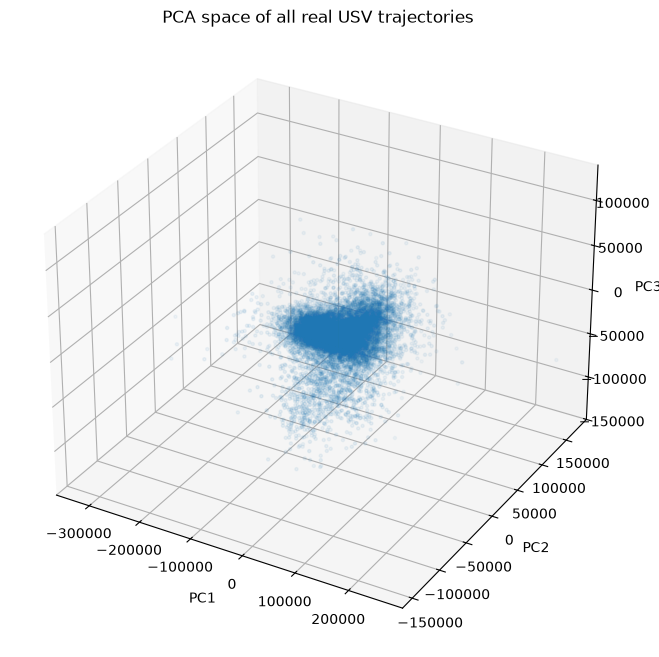

In [ ]:
# project all trajectories into PCA space (already computed as all_pca_vectors, or recompute)
all_trajectories_arr = np.array(train_resampled_trajectories)
means = all_trajectories_arr.mean(axis=1, keepdims=True)
centered = all_trajectories_arr - means
pca_coords = pca_full.transform(centered)[:, :3]  # first 3 components for a 3D-style plot

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_coords[:, 0], pca_coords[:, 1], pca_coords[:, 2], alpha=0.3, s=5)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("PCA space of all real USV trajectories")
plt.show()

epoch 0: train = 6.3192 kHz, test = 5.7305 kHz
epoch 1: train = 5.2690 kHz, test = 5.3218 kHz
epoch 2: train = 4.9112 kHz, test = 4.5734 kHz
epoch 3: train = 4.4565 kHz, test = 4.7240 kHz
epoch 4: train = 4.2715 kHz, test = 4.2799 kHz
epoch 5: train = 4.1403 kHz, test = 4.8263 kHz
epoch 6: train = 3.9882 kHz, test = 4.9331 kHz
epoch 7: train = 3.7251 kHz, test = 3.7019 kHz
epoch 8: train = 3.5319 kHz, test = 3.4614 kHz
epoch 9: train = 3.3638 kHz, test = 4.5541 kHz
epoch 10: train = 3.1733 kHz, test = 4.2108 kHz
epoch 11: train = 3.0198 kHz, test = 3.1102 kHz
epoch 12: train = 2.8421 kHz, test = 2.9395 kHz
epoch 13: train = 2.8791 kHz, test = 2.9744 kHz
epoch 14: train = 2.7349 kHz, test = 3.1392 kHz
epoch 15: train = 2.6934 kHz, test = 3.1740 kHz
epoch 16: train = 2.5542 kHz, test = 2.8243 kHz
epoch 17: train = 2.4290 kHz, test = 2.4785 kHz
epoch 18: train = 2.4460 kHz, test = 2.9926 kHz
epoch 19: train = 2.3655 kHz, test = 2.3477 kHz
epoch 20: train = 2.2191 kHz, test = 2.2003 kHz
ep

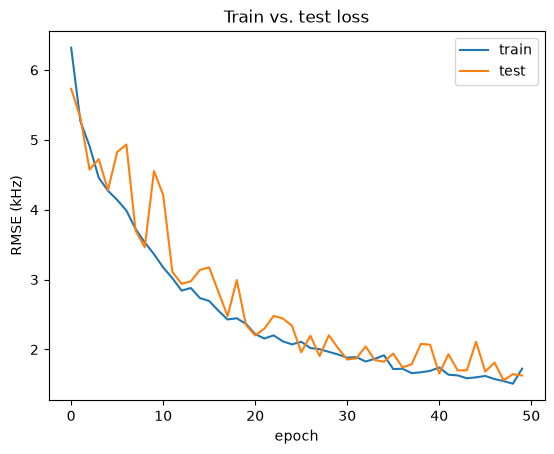

In [9]:
model = LSTMController(pca_dim=11)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

batch_size = 128
epochs = 50

train_losses = []
test_losses = []

for epoch in range(epochs):
    epoch_losses = []
    for i in range(0, len(train_resampled_trajectories), batch_size):
        batch = train_resampled_trajectories[i:i + batch_size]
        pca_vectors, targets = prepare_batch(batch, pca_full, scaler)

        optimizer.zero_grad()
        activations = model(pca_vectors)
        resp, PCAIA, CT, TA = activations[...,0], activations[...,1], activations[...,2], activations[...,3]

        pressure = subglottal_pressure(resp)
        g_area = glottal_area(PCAIA, TA)
        imp_length = impingement_length(CT, TA)
        speed = jet_speed_from_pressure(g_area, pressure)
        predicted_f0 = USVfreq(speed, imp_length)

        loss = torch.sqrt(torch.nn.functional.mse_loss(predicted_f0 / 1000, targets / 1000))
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    avg_train_loss = sum(epoch_losses) / len(epoch_losses)
    avg_test_loss = evaluate(test_resampled_trajectories, model, pca_full, scaler, batch_size)

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    print(f"epoch {epoch}: train = {avg_train_loss:.4f} kHz, test = {avg_test_loss:.4f} kHz")

plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("epoch")
plt.ylabel("RMSE (kHz)")
plt.legend()
plt.title("Train vs. test loss")
plt.show()

--- trajectory 0 ---
real: [54140.6015625, 65610.796875, 65859.3984375, 67198.203125, 67382.796875, 67382.796875, 68359.3984375, 68789.1015625, 68789.1015625, 68789.1015625, 73468.296875, 78984.3984375, 78984.3984375, 78984.3984375, 79101.6015625, 80209.5, 81914.1015625, 81914.1015625, 46992.19921875, 48660.0, 48750.0, 48884.8984375, 48984.3984375, 49687.5, 49687.5, 50035.5, 50039.1015625, 50039.1015625, 49835.5, 49804.69921875, 49804.69921875, 49687.5, 49335.8984375, 49335.8984375, 49335.8984375, 49335.8984375, 48632.80078125, 48632.80078125, 48632.80078125, 47936.80078125, 46992.19921875, 46992.19921875, 46992.19921875, 45672.30078125, 45403.6015625, 44765.6015625, 44765.6015625, 44519.3984375, 44378.6015625, 43813.8984375, 43125.0, 43125.0, 42809.0, 42672.80078125, 43125.0, 62356.80078125, 67734.3984375, 67734.3984375, 67265.6015625, 67265.6015625, 67265.6015625, 66562.5, 66562.5, 66562.5, 66562.5, 65742.203125, 65585.8984375, 65390.6015625, 65361.0, 65156.19921875, 65055.6015625, 6

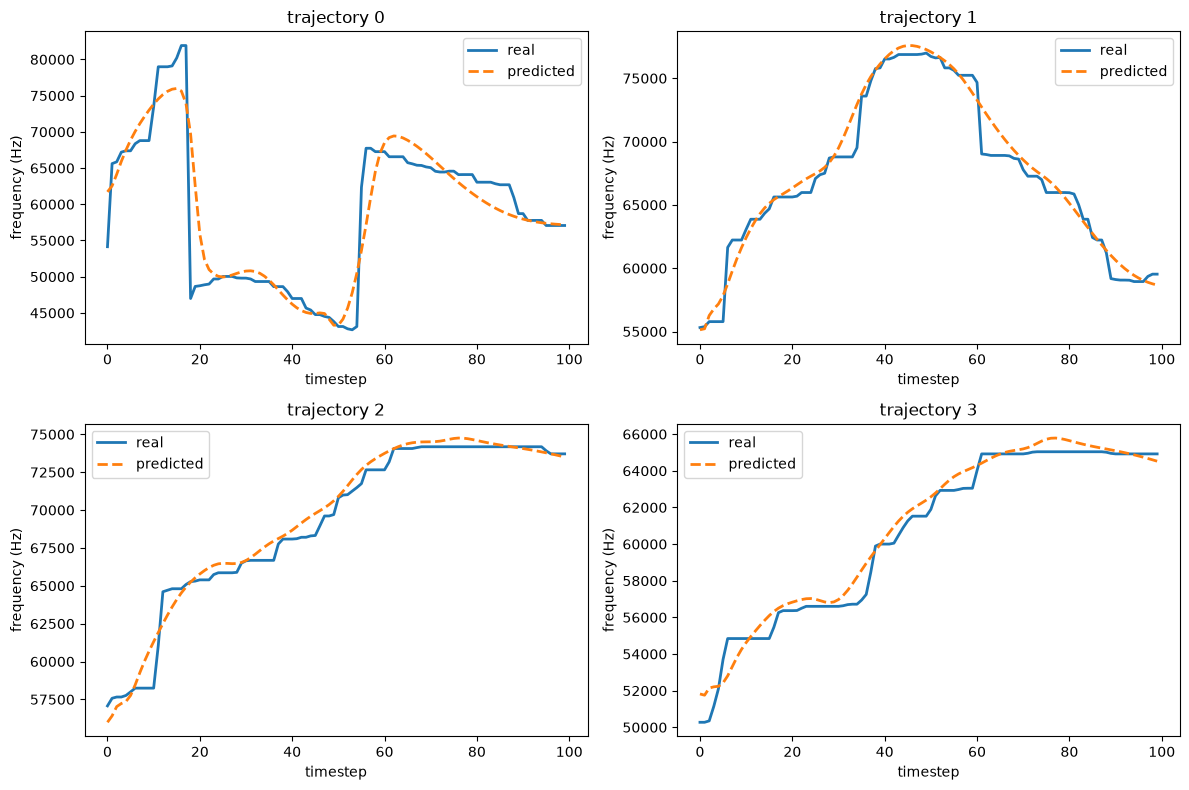

In [14]:
sample_indices = [0, 1, 2, 3]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

with torch.no_grad():
    for ax, idx in zip(axes, sample_indices):
        #trajectory = train_resampled_trajectories[idx]
        trajectory = test_resampled_trajectories[idx]
        pca_vector, target = prepare_batch([trajectory], pca_full, scaler, pca_dim=10)

        activations = model(pca_vector)
        resp, PCAIA, CT, TA = activations[...,0], activations[...,1], activations[...,2], activations[...,3]

        pressure = subglottal_pressure(resp)
        g_area = glottal_area(PCAIA, TA)
        imp_length = impingement_length(CT, TA)
        speed = jet_speed_from_pressure(g_area, pressure)
        predicted = USVfreq(speed, imp_length)

        real_vals = target[0].numpy()
        pred_vals = predicted[0].numpy()

        # --- plot ---
        ax.plot(real_vals, label="real", linewidth=2)
        ax.plot(pred_vals, label="predicted", linewidth=2, linestyle="--")
        ax.set_title(f"trajectory {idx}")
        ax.set_xlabel("timestep")
        ax.set_ylabel("frequency (Hz)")
        ax.legend()

        # --- full point printout ---
        print(f"--- trajectory {idx} ---")
        print("real:", np.round(real_vals, 1).tolist())
        print("predicted:", np.round(pred_vals, 1).tolist())
        print()

plt.tight_layout()
plt.show()

In [15]:
# ------------- don't run anything below here, just keep for reference -------------

epoch 0: loss = 18.66196 kHz
epoch 20: loss = 3.52798 kHz
epoch 40: loss = 0.98461 kHz
epoch 60: loss = 0.42107 kHz
epoch 80: loss = 0.42057 kHz
epoch 100: loss = 0.40506 kHz
epoch 120: loss = 0.40019 kHz
epoch 140: loss = 0.39594 kHz
epoch 160: loss = 0.39162 kHz
epoch 180: loss = 0.38701 kHz
epoch 200: loss = 0.38214 kHz
epoch 220: loss = 0.37702 kHz
epoch 240: loss = 0.37167 kHz
epoch 260: loss = 0.36610 kHz
epoch 280: loss = 0.36033 kHz
final loss: 0.35 kHz


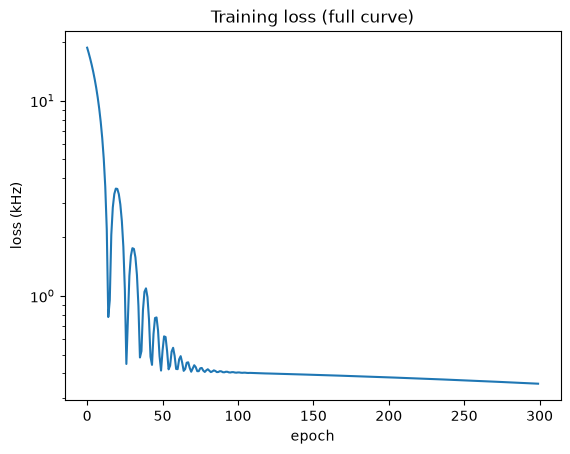

predicted f0 range:96542.2890625 - 99511.75 Hz
target f0 range:99257.8125 - 99609.375 Hz
beta range: 0.5591141581535339 0.5645471215248108


In [ ]:
model = LSTMController(pca_dim=11)

# --- training loop with completely synethetic target f0 ---

# lr = 1e-2 works well w MSE loss @ 300 epochs
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# need to reimport sample_trajectories as from pkl for this to work (older version)
real_trajectory = train_resampled_trajectories[0]
real_trajectory_centered = real_trajectory - real_trajectory.mean()
real_pca_vector = pca_full.transform(real_trajectory_centered.reshape(1, -1))[:, :10]
pca_vector = torch.tensor(real_pca_vector, dtype=torch.float32)

real_target_f0 = torch.tensor(real_trajectory, dtype=torch.float32).unsqueeze(0)

losses = []

for epoch in range(300):
    optimizer.zero_grad()

    activations = model(pca_vector)
    resp_activity = activations[..., 0]
    PCAIA_activity = activations[..., 1]
    CT_activity = activations[..., 2]
    TA_activity = activations[..., 3]

    pressure = subglottal_pressure(resp_activity)
    g_area = glottal_area(PCAIA_activity, TA_activity)
    imp_length = impingement_length(CT_activity, TA_activity)
    speed = jet_speed_from_pressure(g_area, pressure)
    predicted_f0 = USVfreq(speed, imp_length)

    predicted_f0_khz = predicted_f0 / 1000
    target_f0_khz = real_target_f0 / 1000
    loss = torch.sqrt(torch.nn.functional.mse_loss(predicted_f0_khz, target_f0_khz))

    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 20 == 0:
        print(f"epoch {epoch}: loss = {loss.item():.5f} kHz")

print(f"final loss: {losses[-1]:.2f} kHz")

# graph loss over time
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss (kHz)")
plt.yscale("log")  # helpful when values span multiple orders of magnitude
plt.title("Training loss (full curve)")
plt.show()

# check the mucsle activations after training
with torch.no_grad():
    activations_start_check = model(pca_vector)
    pred_check = USVfreq(
        jet_speed_from_pressure(
            glottal_area(activations_start_check[...,1], activations_start_check[...,3]),
            subglottal_pressure(activations_start_check[...,0])
        ),
        impingement_length(activations_start_check[...,2], activations_start_check[...,3])
    )
    print("predicted f0 range:" + str(pred_check.min().item()) + " - " + str(pred_check.max().item()) + " Hz")
    print("target f0 range:" + str(real_target_f0.min().item()) + " - " + str(real_target_f0.max().item()) + " Hz")

    g_area_check = glottal_area(activations_start_check[...,1], activations_start_check[...,3])
    tracheal_diameter = 2 * torch.sqrt(torch.tensor(0.95e-6) / torch.pi)
    glottal_diameter = 2 * torch.sqrt(g_area_check / torch.pi)
    beta_check = glottal_diameter / tracheal_diameter
    print("beta range:", beta_check.min().item(), beta_check.max().item())

In [9]:
# get one real pca vector working

with open("../data_prep/pkl-files/sample_trajectories.pkl", "rb") as f:
    sample_trajectories = pickle.load(f)

print(f"Loaded {len(sample_trajectories)} sample trajectories, shape of first:", sample_trajectories[0].shape)

Loaded 10 sample trajectories, shape of first: (100,)
